In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import math 
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

def make_timedelta(df, col):
    df['seconds'] = df[col]
    df[col] = pd.to_timedelta(df[col], unit='s')

In [134]:
XXSMALL_SIZE = 11
XSMALL_SIZE = 13
SMALL_SIZE = 17
MEDIUM_SIZE = 19
BIGGER_SIZE = 21

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']


colors = [CB_color_cycle[4], CB_color_cycle[7]]

# Benchmark of 10Mb reference vs 10Mb query

In [135]:
min_len = 50
window_size = 20
ref_size = "10Mb_equal"

In [136]:
def get_runtime_df(filename):
    df = pd.read_csv(filename, sep = "\t")
    df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "adapt_cutoff", "errors", "more"]
    more = df['more'].str.split('--',expand=True)

    df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)

    more.drop([9, 13, 15], axis = 1, inplace = True)
    more[0] = more[0].astype(str)

    to_remove = []
    for col in more.columns:
        #print(col)
        #print(more[col])
        if (len(np.unique(more[col])) == 1):
            to_remove.append(col)

    to_remove.append(14)
    more.drop(to_remove, axis = 1, inplace = True)

    more.columns = ["exec-path", "seg-count", "cart-max-capacity", "max-queued-carts", "error-rate", "threads"]
    more["exec-path"] = more["exec-path"].str.removeprefix("/group/ag_abi/evelina/valik/")
    more["exec-path"] = more["exec-path"].str.removesuffix("/bin/dream-stellar search ")

    for col in ["seg-count", "cart-max-capacity", "max-queued-carts", "threads", "error-rate"]:
        more[col] = more[col].str.removeprefix(col)

    col = "output-path"
    if col in more.columns:
        more[col] = more[col].str.removeprefix("output /buffer/ag_abi/evelina/markov/")
        more[["ref-size", "type", "er", "output-type"]] = more[col].str.split('/',expand=True)
        more.drop(["output-path", "output-type", "type"], axis = 1, inplace = True)

    col = "error-rate"
    more[col] = more[col].str.removeprefix("efficiency_")
    df = df.merge(more, how = "outer", left_index = True, right_index = True)
    df = df.astype({'Memory (kb)': 'int64', "seg-count": 'int32', "cart-max-capacity": 'int32', "threads": 'int64', "max-queued-carts" : 'int32', "error-rate" : 'float'})
    return df


In [137]:
def get_seg_len_df(filename):
    df = pd.read_csv(filename, sep = "\t", header = None)
    df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "adapt_cutoff", "errors", "more"]
    more = df['more'].str.split('--',expand=True)
    df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)

    more.drop([1, 2, 6, 7, 8, 9, 10, 13, 14, 15], axis = 1, inplace = True)
    more[0] = more[0].astype(str)
    more.columns = ["exec-path", "seg-count", "cart-max-capacity", "max-queued-carts", "error-rate", "threads"]
    more["exec-path"] = more["exec-path"].str.removeprefix("/group/ag_abi/evelina/valik/")
    more["exec-path"] = more["exec-path"].str.removesuffix("/bin/dream-stellar search ")

    for col in ["seg-count", "cart-max-capacity", "max-queued-carts", "threads", "error-rate"]:
        more[col] = more[col].str.removeprefix(col)

    col = "output-path"
    if col in more.columns:
        more[col] = more[col].str.removeprefix("output /buffer/ag_abi/evelina/markov/")
        more[["ref-size", "type", "er", "output-type"]] = more[col].str.split('/',expand=True)
        more.drop(["output-path", "output-type", "type"], axis = 1, inplace = True)

    col = "error-rate"
    more[col] = more[col].str.removeprefix("efficiency_")
    df = df.merge(more, how = "outer", left_index = True, right_index = True)
    df = df.astype({'Memory (kb)': 'int64', "seg-count": 'int32', "cart-max-capacity": 'int32', "threads": 'int64', "max-queued-carts" : 'int32', "error-rate" : 'float'})
    return df

def get_no_time_df(filename):
    df = pd.read_csv(filename, sep = "\t", header = None)
    df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "adapt_cutoff", "errors", "more"]
    more = df['more'].str.split('--',expand=True)
    df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)

    more.drop([1, 2, 6, 7, 9, 12, 13, 14], axis = 1, inplace = True)
    more[0] = more[0].astype(str)
    more.columns = ["exec-path", "seg-count", "cart-max-capacity", "max-queued-carts", "index", "error-rate", "threads"]
    more["exec-path"] = more["exec-path"].str.removeprefix("/group/ag_abi/evelina/valik/")
    more["exec-path"] = more["exec-path"].str.removesuffix("/bin/dream-stellar search ")

    for col in ["seg-count", "cart-max-capacity", "max-queued-carts", "threads", "error-rate"]:
        more[col] = more[col].str.removeprefix(col)

    col = "index"
    more[col] = more[col].str.removeprefix("index /dev/shm/markov/" + ref_size + "/")
    more[col] = more[col].str.removesuffix(".index ")

    #print(len(more[col].iloc[0].split('_')))
    if (len(more[col].iloc[0].split('_')) == 3):
        more[["rep", "e", "bins", "end"]] = more[col].str.split('_',expand=True)
        more.drop(["e", "end", "index"], axis = 1, inplace = True)
    else:
        print(len(more[col].iloc[0].split('_')))
        more[["rep", "e", "bins"]] = more[col].str.split('_',expand=True)
        more.drop(["e", "index"], axis = 1, inplace = True)
    
    col = "rep"
    more[col] = more[col].str.removeprefix(col)
    col = "bins"
    more[col] = more[col].str.removeprefix("b")
    
    col = "output-path"
    if col in more.columns:
        more[col] = more[col].str.removeprefix("output /buffer/ag_abi/evelina/markov/")
        more[["ref-size", "type", "er", "output-type"]] = more[col].str.split('/',expand=True)
        more.drop(["output-type", "type"], axis = 1, inplace = True)

    col = "error-rate"
    more[col] = more[col].str.removeprefix("efficiency_")
    df = df.merge(more, how = "outer", left_index = True, right_index = True)
    df = df.dropna()
    df = df[df["rep"] != "seg"]
    df = df.astype({'Memory (kb)': 'int64', "seg-count": 'int32', "cart-max-capacity": 'int32', "threads": 'int64', "max-queued-carts" : 'int32', "error-rate" : 'float', "bins" : 'int32'})
    return df

def get_df(filename):
    df = pd.read_csv(filename, sep = "\t", header = None)
    df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "adapt_cutoff", "errors", "more"]
    more = df['more'].str.split('--',expand=True)
    df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)

    more.drop([1, 2, 6, 7, 9, 12, 13, 14], axis = 1, inplace = True)
    more[0] = more[0].astype(str)
    more.columns = ["exec-path", "seg-count", "cart-max-capacity", "max-queued-carts", "index", "error-rate", "threads"]
    more["exec-path"] = more["exec-path"].str.removeprefix("/group/ag_abi/evelina/valik/")
    more["exec-path"] = more["exec-path"].str.removesuffix("/bin/dream-stellar search ")

    for col in ["seg-count", "cart-max-capacity", "max-queued-carts", "threads", "error-rate"]:
        more[col] = more[col].str.removeprefix(col)

    col = "index"
    more[col] = more[col].str.removeprefix("index /dev/shm/markov/" + ref_size + "/")
    more[col] = more[col].str.removesuffix(".index ")

    more[["rep", "e", "bins"]] = more[col].str.split('_',expand=True)
    more.drop(["e", "index"], axis = 1, inplace = True)
    
    col = "rep"
    more[col] = more[col].str.removeprefix(col)
    col = "bins"
    more[col] = more[col].str.removeprefix("b")
    
    col = "output-path"
    if col in more.columns:
        more[col] = more[col].str.removeprefix("output /buffer/ag_abi/evelina/markov/")
        more[["ref-size", "type", "er", "output-type"]] = more[col].str.split('/',expand=True)
        more.drop(["output-type", "type"], axis = 1, inplace = True)

    col = "error-rate"
    more[col] = more[col].str.removeprefix("efficiency_")
    df = df.merge(more, how = "outer", left_index = True, right_index = True)
    df = df.dropna()
    df = df[df["rep"] != "seg"]
    df = df.astype({'Memory (kb)': 'int64', "seg-count": 'int32', "cart-max-capacity": 'int32', "threads": 'int64', "max-queued-carts" : 'int32', "error-rate" : 'float', "bins" : 'int32'})
    return df


build executable reads all sequences to memory

build_io executable fetches sequences on demand

#### Threads

In [138]:
dir_name = "threads_test"
er_str = "0.06"

threads = [1, 2, 4, 8, 16]
for t in threads:
    frames = []
    for rep in range(1, 6, 1):
        df = get_df(ref_size + "/read_all/" + dir_name + "/efficiency_rep" + str(rep) + "_e" + er_str + "/search_efficiency_rep" + str(rep) + "_e" + er_str + ".log")
        acc = pd.read_csv(ref_size + "/read_all/" + dir_name + "/efficiency_rep" + str(rep) + "_e" + er_str + "/valik.stellar.accuracy", sep = "\t", header = None)
        
        acc.drop([0, 6, 7, 8], inplace = True, axis = 1)
        acc.columns = ["test-set-matches", "truth-set-matches", "true-positives", "missed", "adapt_cutoff"]
        acc["threads"] = threads
        df = pd.merge(df, acc, on = ["threads", "adapt_cutoff"], how = "inner")
        frames.append(df)
    data = pd.concat(frames)

data.drop(["rep"], axis = 1, inplace = True)

In [139]:
data["Memory (Mb)"] = (data["Memory (kb)"] / 1000).astype(int)
data.drop(["Memory (kb)"], axis = 1, inplace = True)

d = data[["threads", "Time (s)", "Memory (Mb)", "missed"]]
d = d.groupby('threads').agg('mean')
d = d.round({"Time (s)" : 1, "missed" : 4})
d

,Time (s),Memory (Mb),missed
threads,,,
1,23.2,156.6,0.0072
2,11.7,227.0,0.0072
4,6.1,337.8,0.0072
8,3.3,464.8,0.0072
16,2.0,774.8,0.0072


In [140]:
def get_stellar_df(filename):
    df = pd.read_csv(filename, sep = "\t", header = None)
    df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "more"]
    more = df['more'].str.split('--',expand=True)

    df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)

    more.drop([0, 1, 2, 3, 4, 5, 6, 7,8, 10, 11, 12], axis = 1, inplace = True)
    more.columns = ["threads"]
    col = "threads"
    more[col] = more[col].str.removeprefix("threads")
    
    df = df.merge(more, how = "outer", left_index = True, right_index = True)
    df = df.dropna()
    df = df.astype({'Memory (kb)': 'int64', "threads": 'int64'})
    return df

for t in threads:
    frames = []
    for rep in range(1, 6, 1):
        df = get_stellar_df(ref_size + "/read_all/" + dir_name + "/efficiency_rep" + str(rep) + "_e" + er_str + "/stellar_efficiency_rep" + str(rep) + "_e" + er_str + ".log")
        frames.append(df)
    stellar = pd.concat(frames)
    
stellar["Memory (Mb)"] = (stellar["Memory (kb)"] / 1000).astype(int)
stellar.drop(["Memory (kb)"], axis = 1, inplace = True)
stellar = stellar.groupby('threads').agg('mean')
stellar = stellar.round({"Time (s)" : 1})
stellar

,Time (s),Memory (Mb)
threads,,
1,96.2,405.2
2,48.3,767.2
4,29.2,1486.4
8,14.8,2861.2
16,10.1,5653.2


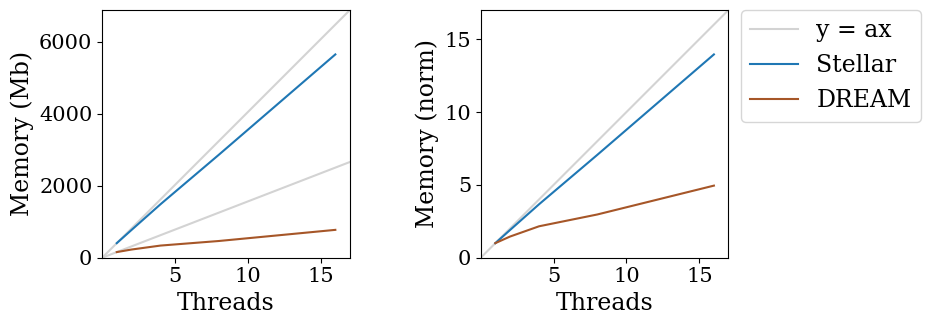

In [141]:
XXSMALL_SIZE = 9
XSMALL_SIZE = 11
SMALL_SIZE = 15
MEDIUM_SIZE = 17
BIGGER_SIZE = 19

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

fig, ax = plt.subplots(1, 2)
fig.set_size_inches(10, 3.5)

col = "Memory (Mb)"
# Plot DREAM linear growth
min_mem = np.min(d[col])
threads = list(d.index)
threads.insert(0, 0)
threads.insert(6, 17)
line = list(np.array(threads)*min_mem)
ax[0].plot(threads, line, color = "lightgray")

line = list(np.array(threads)*min_mem / np.min(d[col]))
ax[1].plot(threads, line, color = "lightgray", label = "y = ax")

ax[0].set_box_aspect(1)
ax[1].set_box_aspect(1)

# Plot Stellar linear growth
min_mem = stellar[col].iloc[0]
threads = list(stellar.index)
threads.insert(0, 0)
threads.insert(6, 17)
line = list(np.array(threads)*min_mem)
ax[0].plot(threads, line, color = "lightgray", label = "y = ax")

# Plot absolute memory usage
ax[0].plot(d.index, stellar[col], label = r"Stellar")
ax[0].plot(d.index, d[col], label = r"DREAM", color = colors[0])


ax[0].set_ylim([0, np.max(line)])
ax[0].set_xlim([0, 17])

ax[0].set_ylabel(col)
ax[0].set_xlabel("Threads")
ax[0].set_box_aspect(1)

# Plot normalized memory usage
ax[1].plot(d.index, stellar[col] / np.min(stellar[col]), label = r"Stellar")
ax[1].plot(d.index, d[col] / np.min(d[col]), label = r"DREAM", color = colors[0])

ax[1].set_ylim([0, 17])
ax[1].set_xlim([0, 17])

ax[1].set_ylabel(r"Memory (norm)")
ax[1].set_xlabel("Threads")
ax[1].set_box_aspect(1)
ax[1].legend(bbox_to_anchor = (1.05, 1),  loc='upper left', borderaxespad=0.)

ax[1].legend(bbox_to_anchor = (1.05, 1),  loc='upper left', borderaxespad=0.)

for i in range(2):
    ax[i].set_xticks([5, 10, 15])

fig.tight_layout()  # otherwise the right y-label is slightly clipped
fig.savefig(ref_size + "_thread_memory.png", dpi=400, bbox_inches='tight')
plt.show()

In [142]:
ibf_size = 17508570
database_size = 10 * 1024 * 1024
query_size = 10 *1024 * 1024

data["memory-model"] = ((data["Memory (Mb)"] * 10**6 - (ibf_size + 2 * database_size + 2 * query_size)) / 10**6).astype(int)


data["memory-model-error (%)"] = np.round(data["memory-model"] / data["Memory (Mb)"] * 100, 2)
#data

#### Error rate test

In [143]:
def get_er_df(filename):
    df = pd.read_csv(filename, sep = "\t", header = None)
    df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "adapt_cutoff", "errors", "more"]
    
    more = df['more'].str.split('--',expand=True)
    df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)

    more.drop([1, 2, 6, 7, 9, 12, 13, 14], axis = 1, inplace = True)
    more[0] = more[0].astype(str)
    more.columns = ["exec-path", "seg-count", "cart-max-capacity", "max-queued-carts", "index", "error-rate", "threads"]
    more["exec-path"] = more["exec-path"].str.removeprefix("/group/ag_abi/evelina/valik/")
    more["exec-path"] = more["exec-path"].str.removesuffix("/bin/dream-stellar search ")

    for col in ["seg-count", "cart-max-capacity", "max-queued-carts", "threads", "error-rate"]:
        more[col] = more[col].str.removeprefix(col)

    col = "index"
    more[col] = more[col].str.removeprefix("index /dev/shm/markov/" + ref_size + "/")
    more[col] = more[col].str.removesuffix(".index ")

    more[["seg", "rep", "e", "bins"]] = more[col].str.split('_',expand=True)
    more.drop(["seg", "e", "index"], axis = 1, inplace = True)
    
    col = "rep"
    more[col] = more[col].str.removeprefix(col)
    col = "bins"
    more[col] = more[col].str.removeprefix("b")
    
    col = "output-path"
    if col in more.columns:
        more[col] = more[col].str.removeprefix("output /buffer/ag_abi/evelina/markov/")
        more[["ref-size", "type", "er", "output-type"]] = more[col].str.split('/',expand=True)
        more.drop(["output-type", "type"], axis = 1, inplace = True)

    col = "error-rate"
    more[col] = more[col].str.removeprefix("efficiency_")
    df = df.merge(more, how = "outer", left_index = True, right_index = True)
    df = df.dropna()
    df = df[df["rep"] != "seg"]
    df = df.astype({'Memory (kb)': 'int64', "seg-count": 'int32', "cart-max-capacity": 'int32', "threads": 'int64', "max-queued-carts" : 'int32', "error-rate" : 'float', "bins" : 'int32'})
    return df


ref_size = "10Mb_equal"
bin_cutoff = 0.5
dir_name = "error_rate_test"
ref_len = 10 * 1024 * 1024
b = 1024
print("Error rate\tTime (s)\tMemory (Mb)\tMissed")
for er in [0.02, 0.04, 0.06, 0.08, 0.1]:
    frames = []
    for rep in range(2, 6, 1):
        er_str = str(er)
        if (er == 0.1):
            er_str = "0.10"
        df = get_er_df(ref_size + "/read_all/" + dir_name + "/efficiency_rep" + str(rep) + "_e" + er_str + "/search_efficiency_rep" + str(rep) + "_e" + er_str + ".log")
        acc = pd.read_csv(ref_size + "/read_all/" + dir_name + "/efficiency_rep" + str(rep) + "_e" + er_str + "/valik.stellar.accuracy", sep = "\t", header = None)
        
        acc.drop([0, 6, 7, 8], inplace = True, axis = 1)
        acc.columns = ["test-set-matches", "truth-set-matches", "true-positives", "missed", "adapt_cutoff"]
            
        df = pd.merge(df, acc, on = ["adapt_cutoff"], how = "inner")
        df["seg-len"] = (ref_len / df["bins"]).astype(int)
        frames.append(df)
    data = pd.concat(frames)
        
    print(str(er) + "\t" +  
            str(np.round(np.mean(data[data["bins"]==b]["Time (s)"]), 1)) + "\t" +  
                str(np.round(np.mean(data[data["bins"]==b]["Memory (kb)"]) / 1000, 1)) + "\t" +
                        str(np.round(np.mean(data[data["bins"]==b]["missed"]) * 100, 1)))

Error rate	Time (s)	Memory (Mb)	Missed
0.02	6.4	120.3	0.4
0.04	5.2	320.0	0.0
0.06	6.1	323.4	0.7
0.08	38.7	341.8	1.2
0.1	75.1	337.4	2.4


#### Cart parameters

In [144]:
XXSMALL_SIZE = 11
XSMALL_SIZE = 13
SMALL_SIZE = 17
MEDIUM_SIZE = 19
BIGGER_SIZE = 21

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

In [332]:
def plot_cols(data, ax, column, color, label):
    capacities = [1, 2, 4, 1000]
    data_list = []
    for c in capacities:
        data_list.append(data[data["max-queued-carts"]==c][column])
        
    bplot = ax.boxplot(data_list,
                       patch_artist=True,  # fill with color
                       tick_labels=capacities)  # will be used to label x-ticks

    # fill with colors
    local_colors = [color] * len(capacities)
    for patch, color in zip(bplot['boxes'], local_colors):
        patch.set_facecolor(color)

    legend_square = mpatches.Patch(color=color, label=label)
    #ax.legend(handles=[legend_square])

def get_kmer_index_size(t, query0, cart_capacities_array):    
    seg_len = query_size / build["seg-count"].iloc[0]
    qgrams_per_segment = int(seg_len - qgram_size + 1)
    seqan2_seq_size = seg_len * cart_capacities_array * t / 10**6 
    # does q-gram index size vary depending on the q-gram content?
    #fullness = (1 + 1 - qindex_full) * bytes_per_qgram
    #kmer_index_size = t * size_correction * qgrams_per_segment * fullness / 10**6 + seqan2_seq_size + query0
    
    fullness = 3 * bytes_per_qgram
    kmer_index_size = t * size_correction * qgrams_per_segment * fullness / 10**6 + seqan2_seq_size + query0
    #print(kmer_index_size - query0 + seqan2_seq_size)
    return kmer_index_size

Theoretical memory model

In [337]:
ibf_size = (17944233 + 41414 + 390) * 10
database_size = 100 * 10**6
query_size = 10 * 10**6

bin_count = 1024
qindex_full = 0.75
qgram_size = 12
bytes_per_qgram = 8 # assuming no repeat k-mers

window_size = 20
bytes_per_window = 1

query_seg_count = 4000
query_segment_size = int(round(query_size / query_seg_count, 0)) 

queue_capacity = 50
hit_coverage = 0.01
bytes_per_DP = 2

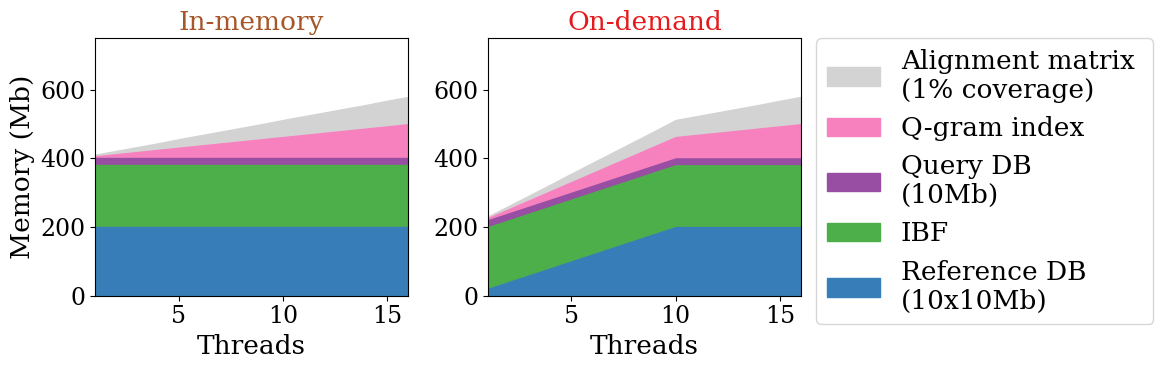

In [341]:
cart_cap = 100
size_correction = cart_cap 

styles = ["-", "-"]
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(12, 4)

labels = ["In-memory", "On-demand"]
#"K-mer index\n(" + str(int(round(100 * qindex_full))) +"% full)"
mem_labels = ["Q-gram index", "Query DB\n(10Mb)", "Query DB", "IBF", "Reference DB\n(10x10Mb)", "Reference DB\n(10x10Mb)", "Alignment matrix \n(" + str(int(round(100 * hit_coverage, 0))) + "% coverage)", "Local filter"]
i = 0
j = 0

column = "Time (s)"

#x_values = range(10 * query_segment_size, 1010 * query_segment_size, 10 * query_segment_size)
#size_correction = np.array(x_values)
#print(size_correction) 
threads = list(range(17))

x_len = len(threads)
zeroes = [0] * x_len
    
databases = [int(np.round(2 * database_size / 10**6, 0))] * x_len
ibf = [int(np.round(ibf_size / 10**6 + databases[0], 0))] * x_len
queries = [int(np.round((2 * query_size) / 10**6 + ibf[0], 0))] * x_len
    
bin_size = database_size / bin_count
    
seg_len = query_size / df["seg-count"].iloc[0] + min_len
kmer_index_size = []
for t in threads:
    kmer_index_size.append(get_kmer_index_size(t, queries[0], np.array([cart_cap]))[0])

alignment_matrix_size = (np.array(threads) * hit_coverage * bytes_per_DP * seg_len * bin_size / 10**6 + kmer_index_size).astype(int)

# In-memory
aks = ax[i]
aks.plot(threads, x_len * [1], color = CB_color_cycle[0])

aks.fill_between(threads, kmer_index_size, alignment_matrix_size, label = mem_labels[6], color = "lightgray")
aks.fill_between(threads, [queries[0]] * x_len, kmer_index_size, label = mem_labels[0], color = CB_color_cycle[3])
aks.fill_between(threads, ibf, queries, label = mem_labels[1], color = CB_color_cycle[5])
aks.fill_between(threads, databases, ibf, label = mem_labels[3], color = CB_color_cycle[2])
aks.fill_between(threads, zeroes, databases, label = mem_labels[4], color = CB_color_cycle[0])

i = 1

# On-demand
aks = ax[i]

database_chr_size = database_size / 10

databases = []
for t in threads:
    databases.append(int(np.round(2 * np.min([t * database_chr_size, database_size]) / 10**6, 0)))

ibf = np.array(databases) + int(np.round(ibf_size / 10**6, 0))
queries =  np.array(ibf) + int(np.round((2 * query_size) / 10**6, 0)) 

kmer_index_size = []
c = 0
for t in threads:
    kmer_index_size.append(get_kmer_index_size(t, queries[c], np.array([cart_cap]))[0])
    c += 1
    
alignment_matrix_size = (np.array(threads) * hit_coverage * bytes_per_DP * seg_len * bin_size / 10**6 + kmer_index_size).astype(int)
aks.plot(threads, x_len * [1], color = CB_color_cycle[0])

aks.fill_between(threads, kmer_index_size, alignment_matrix_size, label = mem_labels[6], color = "lightgray")
aks.fill_between(threads, [queries[0]] * x_len, kmer_index_size, label = mem_labels[0], color = CB_color_cycle[3])
aks.fill_between(threads, ibf, queries, label = mem_labels[1], color = CB_color_cycle[5])
aks.fill_between(threads, databases, ibf, label = mem_labels[3], color = CB_color_cycle[2])
aks.fill_between(threads, zeroes, databases, label = mem_labels[5], color = CB_color_cycle[0])
    
for i in range(0, 2, 1):
    ax[i].set_ylim(0, 750)
    ax[i].set_xlim(1, threads[-1])
        
i = 0
for i in range(2):
    ax[i].set_xlabel("Threads")
ax[0].set_ylabel("Memory (Mb)")

for i in range(2):
    ax[i].set_title(labels[i], color = colors[i])

ax[1].legend(bbox_to_anchor = (1.05, 1),  loc='upper left', borderaxespad=0.)
    
#fig.suptitle(r"Searching 10k $\epsilon$(50, 3)-matches between 100Mb reference and 1Mb query")
fig.tight_layout()  # otherwise the right y-label is slightly clipped
fig.savefig("thread_model_of_memory_usage.png", dpi=400, bbox_inches='tight')
plt.show()

In [317]:
x_values = range(10, 1010, 10)
#size_correction = np.array([x * math.log(10, x) for x in x_values])
size_correction = np.array(x_values)
size_correction

array([  10,   20,   30,   40,   50,   60,   70,   80,   90,  100,  110,
        120,  130,  140,  150,  160,  170,  180,  190,  200,  210,  220,
        230,  240,  250,  260,  270,  280,  290,  300,  310,  320,  330,
        340,  350,  360,  370,  380,  390,  400,  410,  420,  430,  440,
        450,  460,  470,  480,  490,  500,  510,  520,  530,  540,  550,
        560,  570,  580,  590,  600,  610,  620,  630,  640,  650,  660,
        670,  680,  690,  700,  710,  720,  730,  740,  750,  760,  770,
        780,  790,  800,  810,  820,  830,  840,  850,  860,  870,  880,
        890,  900,  910,  920,  930,  940,  950,  960,  970,  980,  990,
       1000])

In [318]:
query_size / query_seg_count

2500.0

1
4


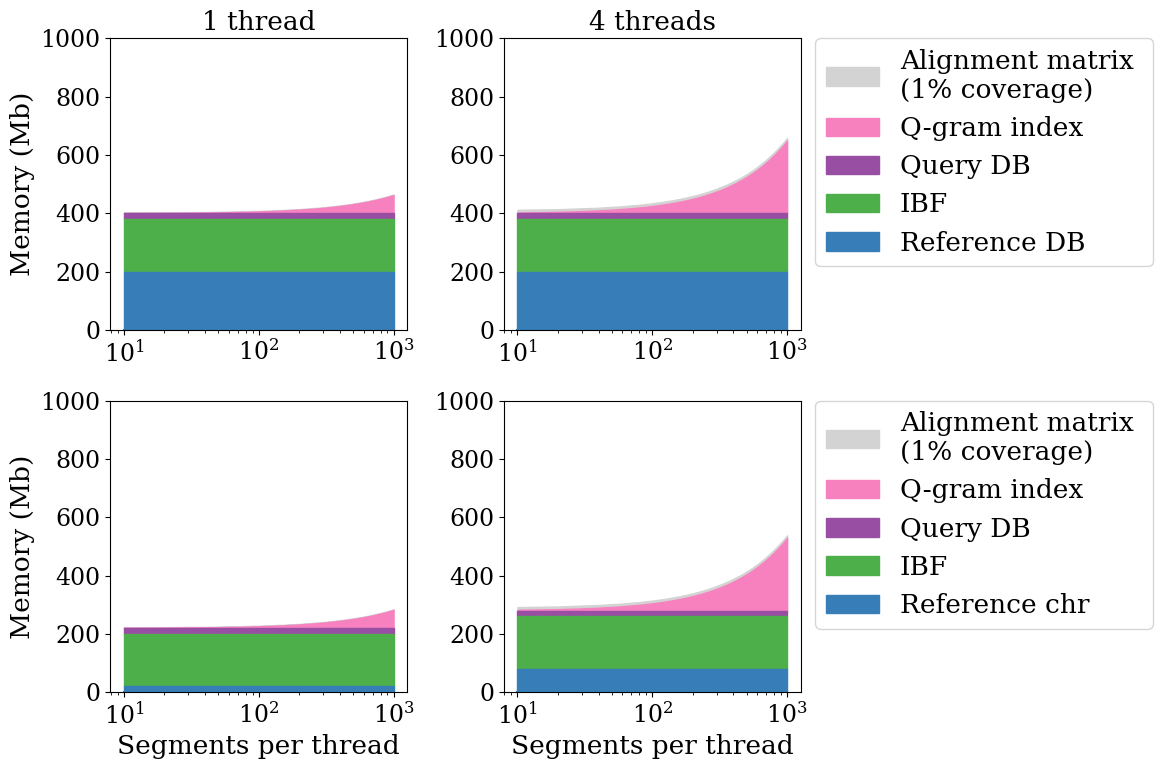

In [319]:
styles = ["-", "-"]
fig, ax = plt.subplots(2, 2)
fig.set_size_inches(12, 8)

labels = ["In-memory", "On-demand"]
#"K-mer index\n(" + str(int(round(100 * qindex_full))) +"% full)"
mem_labels = ["Q-gram index", "Query DB", "Query chr", "IBF", "Reference DB", "Reference chr", "Alignment matrix \n(" + str(int(round(100 * hit_coverage))) + "% coverage)", "Local filter"]
i = 0
j = 0

column = "Time (s)"

#x_values = range(10 * query_segment_size, 1010 * query_segment_size, 10 * query_segment_size)
#size_correction = np.array(x_values)
#print(size_correction) 
for t in [1, 4]:    
    x_len = len(x_values)
    zeroes = [0] * x_len
    
    databases = [int(np.round(2 * database_size / 10**6, 0))] * x_len
    ibf = [int(np.round(ibf_size / 10**6 + databases[0], 0))] * x_len
    queries = [int(np.round((2 * query_size) / 10**6 + ibf[0], 0))] * x_len
    
    bin_size = database_size / bin_count
    
    seg_len = query_size / df["seg-count"].iloc[0] + min_len
    kmer_index_size = get_kmer_index_size(t, queries[0], x_values)

    print(t)
    alignment_matrix_size = (np.array(kmer_index_size) + (t * hit_coverage * seg_len * bin_size / 10**6)).astype(int)

    aks = ax[i][j]
    aks.semilogx(x_values, x_len * [1], color = CB_color_cycle[0])

    #aks.fill_between(x_values, kmer_index_size, data["Memory (kb)"] / 1000, label = mem_labels[6], color = "lightgray")
    aks.fill_between(x_values, kmer_index_size, alignment_matrix_size, label = mem_labels[6], color = "lightgray")
    aks.fill_between(x_values, [queries[0]] * x_len, kmer_index_size, label = mem_labels[0], color = CB_color_cycle[3])
    #aks.fill_between(data.index.values, queries, data["local-filter-size"], label = mem_labels[7], color = CB_color_cycle[6])
    aks.fill_between(x_values, ibf, queries, label = mem_labels[1], color = CB_color_cycle[5])
    aks.fill_between(x_values, databases, ibf, label = mem_labels[3], color = CB_color_cycle[2])
    aks.fill_between(x_values, zeroes, databases, label = mem_labels[4], color = CB_color_cycle[0])

    i = 1

    aks = ax[i][j]

    database_chr_size = database_size / 10
    
    databases = [int(np.round(t * 2 * database_chr_size / 10**6, 0))] * x_len
    ibf = [int(np.round(ibf_size / 10**6 + databases[0], 0))] * x_len
    queries = [int(np.round((2 * query_size) / 10**6 + ibf[0], 0))] * x_len
    
    kmer_index_size = get_kmer_index_size(t, queries[0], x_values)

    #alignment_matrix_size = (data["threads"].iloc[0] * x_values * hit_coverage * seg_len * bin_size / 10**6 + kmer_index_size).astype(int)
    alignment_matrix_size = (np.array(kmer_index_size) + (t * hit_coverage * seg_len * bin_size / 10**6)).astype(int)
    #print(alignment_matrix_size)
    aks.semilogx(x_values, x_len * [1], color = CB_color_cycle[0])

    aks.fill_between(x_values, kmer_index_size, alignment_matrix_size, label = mem_labels[6], color = "lightgray")
    #aks.fill_between(data.index.values, data["kmer-index-size"], data["Memory (kb)"] / 10**3, label = mem_labels[6], color = "lightgray")
    aks.fill_between(x_values, [queries[0]] * x_len, kmer_index_size, label = mem_labels[0], color = CB_color_cycle[3])
    #aks.fill_between(data.index.values, queries, , label = mem_labels[7], color = CB_color_cycle[6])
    aks.fill_between(x_values, ibf, queries, label = mem_labels[1], color = CB_color_cycle[5])
    aks.fill_between(x_values, databases, ibf, label = mem_labels[3], color = CB_color_cycle[2])
    aks.fill_between(x_values, zeroes, databases, label = mem_labels[5], color = CB_color_cycle[0])
    
    i = 0
    j += 1

for i in range(0, 2, 1):
    for j in range(0, 2, 1):
        ax[i][j].set_ylim(0, 1000)
        #ax[i][j].set_ylim(0, np.max(data["Memory (kb)"]) * 1.2 / 1024)
        #ax[i][j].set_xlabel("Cart capacity")
    
i = 1
for j in range(0, 2, 1):
    ax[i][j].set_xlabel("Segments per thread")
j = 0
for i in range(0, 2, 1):
    ax[i][j].set_ylabel("Memory (Mb)")

ax[0][0].set_title("1 thread")
ax[0][1].set_title("4 threads")

ax[0][1].legend(bbox_to_anchor = (1.05, 1),  loc='upper left', borderaxespad=0.)
ax[1][1].legend(bbox_to_anchor = (1.05, 1),  loc='upper left', borderaxespad=0.)
    
#fig.suptitle(r"Searching 10k $\epsilon$(50, 3)-matches between 100Mb reference and 1Mb query")
fig.tight_layout()  # otherwise the right y-label is slightly clipped
fig.savefig("cart_capacity_model_of_memory_usage.png", dpi=400, bbox_inches='tight')
plt.show()

Memory model vs the actual memory usage

In [343]:
ref_size = "10Mb_equal"
df = get_no_time_df(ref_size + "/full.log")
build = df[df["exec-path"] == "build"].copy()

#build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
io = df[df["exec-path"] == "build_io"].copy()
#io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

In [344]:
df_all = df.copy()
df = df[df["seg-count"]==4000]
df = df[df["error-rate"]==0.06]
df = df[df["max-queued-carts"]==1000]
df = df[df["bins"] == 1024]
df.drop(["rep"], axis = 1, inplace = True)

df_cart = df.copy()

In [345]:
build = df[df["exec-path"] == "build"].copy()
build.drop(["adapt_cutoff", "errors", "exec-path", "error-rate"], axis = 1, inplace = True)
io = df[df["exec-path"] == "build_io"].copy()
io.drop(["adapt_cutoff", "errors", "exec-path", "error-rate"], axis = 1, inplace = True)

In [346]:
ibf_size = 17944233 + 41414 + 390
database_size = 10 * 1024 * 1024
query_size = 10 * 1024 * 1024

qindex_full = 0.75
qgram_size = 12
bytes_per_qgram = 8 # x3 in the q-gram index

window_size = 20
bytes_per_window = 1

query_seg_count = 4000
query_segment_size = int(round(query_size / query_seg_count, 0)) 

queue_capacity = 50
hit_coverage = 0.05
bytes_per_DP = 1

In [347]:
x_values = range(10, 1010, 10)
#size_correction = np.array([x * math.log(10, x) for x in x_values])
size_correction = np.array(x_values)
size_correction

array([  10,   20,   30,   40,   50,   60,   70,   80,   90,  100,  110,
        120,  130,  140,  150,  160,  170,  180,  190,  200,  210,  220,
        230,  240,  250,  260,  270,  280,  290,  300,  310,  320,  330,
        340,  350,  360,  370,  380,  390,  400,  410,  420,  430,  440,
        450,  460,  470,  480,  490,  500,  510,  520,  530,  540,  550,
        560,  570,  580,  590,  600,  610,  620,  630,  640,  650,  660,
        670,  680,  690,  700,  710,  720,  730,  740,  750,  760,  770,
        780,  790,  800,  810,  820,  830,  840,  850,  860,  870,  880,
        890,  900,  910,  920,  930,  940,  950,  960,  970,  980,  990,
       1000])

1
4


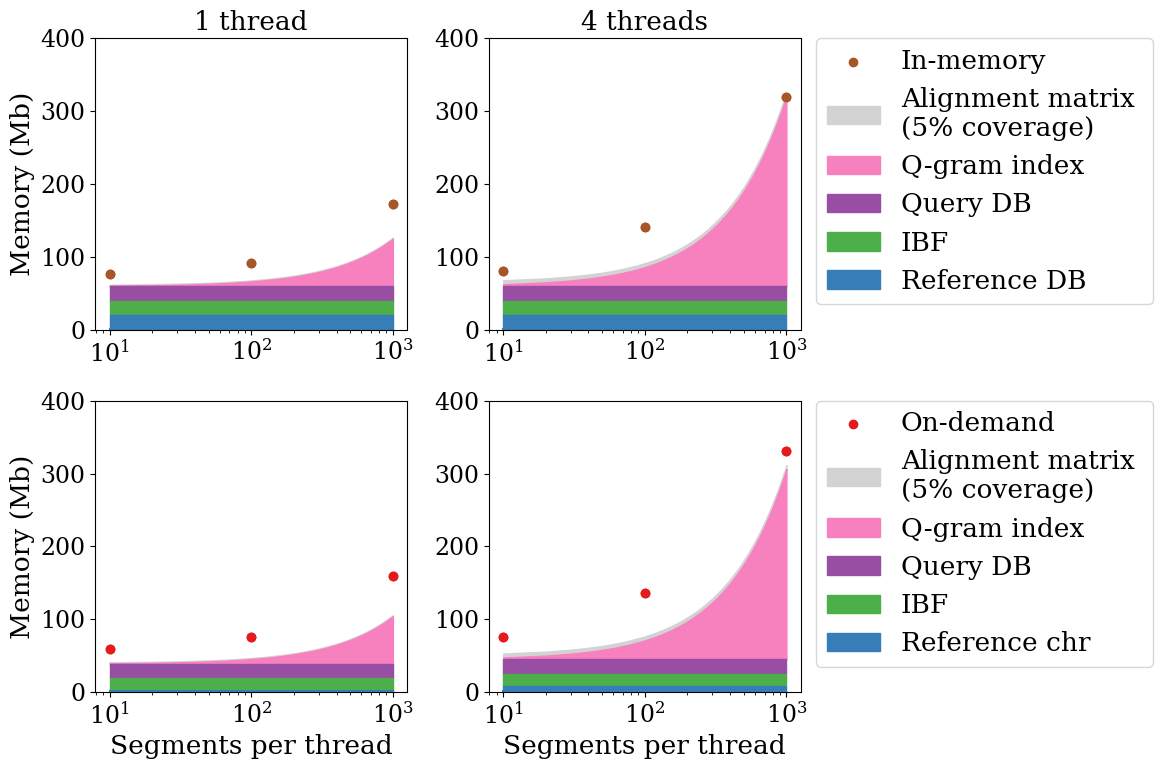

In [348]:
styles = ["-", "-"]
fig, ax = plt.subplots(2, 2)
fig.set_size_inches(12, 8)

labels = ["In-memory", "On-demand"]

#"K-mer index\n(" + str(int(round(100 * qindex_full))) +"% full)"
mem_labels = ["Q-gram index", "Query DB", "Query chr", "IBF", "Reference DB", "Reference chr", "Alignment matrix \n(" + str(int(round(100 * hit_coverage))) + "% coverage)", "Local filter"]
i = 0
j = 0

column = "Time (s)"

#x_values = range(10 * query_segment_size, 1010 * query_segment_size, 10 * query_segment_size)
#size_correction = np.array(x_values)
#print(size_correction) 
for t in [1, 4]:    
    data = build.copy()
    data = data[data["threads"] == t]
    data = data[data["cart-max-capacity"] > 1]
    data = data[data["max-queued-carts"] == 1000]
    data = data.sort_values('cart-max-capacity', ascending=True)
    #data["cart-size"] = data["cart-max-capacity"] * query_segment_size
    #data = data.groupby('cart-size').agg('mean')
    data = data.groupby('cart-max-capacity').agg('mean')
    
    x_len = len(data["Memory (kb)"])
    zeroes = [0] * x_len
    
    databases = [int(np.round(2 * database_size / 10**6, 0))] * x_len
    ibf = [int(np.round(ibf_size / 10**6 + databases[0], 0))] * x_len
    queries = [int(np.round((2 * query_size) / 10**6 + ibf[0], 0))] * x_len
    
    bin_size = database_size / 1024
    
    seg_len = query_size / df["seg-count"].iloc[0] + min_len
    x_len = len(x_values)
    kmer_index_size = get_kmer_index_size(t, queries[0], x_values)

    print(t)

    #alignment_matrix_size = (np.array(x_values) * t * hit_coverage * seg_len * bin_size / 10**6 + kmer_index_size).astype(int)
    alignment_matrix_size = np.array(kmer_index_size) + (t * hit_coverage * bytes_per_DP * seg_len * bin_size / 10**6)
    
    aks = ax[i][j]
    aks.semilogx(x_values, x_len * [1], color = CB_color_cycle[0])

    aks.scatter(data.index.values, data["Memory (kb)"] / 10**3, label = labels[i], color = colors[i])
    #aks.fill_between(x_values, kmer_index_size, data["Memory (kb)"] / 1000, label = mem_labels[6], color = "lightgray")
    aks.fill_between(x_values, kmer_index_size, alignment_matrix_size, label = mem_labels[6], color = "lightgray")
    aks.fill_between(x_values, [queries[0]] * x_len, kmer_index_size, label = mem_labels[0], color = CB_color_cycle[3])
    #aks.fill_between(data.index.values, queries, data["local-filter-size"], label = mem_labels[7], color = CB_color_cycle[6])
    aks.fill_between(data.index.values, ibf, queries, label = mem_labels[1], color = CB_color_cycle[5])
    aks.fill_between(data.index.values, databases, ibf, label = mem_labels[3], color = CB_color_cycle[2])
    aks.fill_between(data.index.values, zeroes, databases, label = mem_labels[4], color = CB_color_cycle[0])

    aks.scatter(data.index.values, data["Memory (kb)"] / 10**3, color = colors[i])
    
    i = 1

    aks = ax[i][j]
    
    data = io.copy()
    data = data[data["threads"] == t]
    data = data[data["cart-max-capacity"] > 1]
    data = data[data["max-queued-carts"] == 1000]
    data = data.sort_values('cart-max-capacity', ascending=True)
    #data["cart-size"] = data["cart-max-capacity"] * query_segment_size
    #data = data.groupby('cart-size').agg('mean')
    data = data.groupby('cart-max-capacity').agg('mean')
    
    x_len = len(data["Memory (kb)"])
    zeroes = [0] * x_len

    database_chr_size = database_size / 10
    
    databases = [math.floor(t * 2 * database_chr_size / 10**6)] * x_len
    ibf = [math.floor(ibf_size / 10**6 + databases[0])] * x_len
    queries = [math.floor((2 * query_size) / 10**6 + ibf[0])] * x_len
    
    x_len = len(x_values)    
    kmer_index_size = get_kmer_index_size(t, queries[0], x_values)

    #alignment_matrix_size = (np.array(x_values) * t * hit_coverage * seg_len * bin_size / 10**6 + kmer_index_size).astype(int)
    alignment_matrix_size = np.array(kmer_index_size) + (t * hit_coverage * bytes_per_DP * seg_len * bin_size / 10**6)
    
    #print(alignment_matrix_size)
    aks.semilogx(x_values, x_len * [1], color = CB_color_cycle[0])

    aks.scatter(data.index.values, data["Memory (kb)"] / 10**3, label = labels[i], color = colors[i])
    aks.fill_between(x_values, kmer_index_size, alignment_matrix_size, label = mem_labels[6], color = "lightgray")
    #aks.fill_between(data.index.values, data["kmer-index-size"], data["Memory (kb)"] / 10**3, label = mem_labels[6], color = "lightgray")
    aks.fill_between(x_values, [queries[0]] * x_len, kmer_index_size, label = mem_labels[0], color = CB_color_cycle[3])
    #aks.fill_between(data.index.values, queries, , label = mem_labels[7], color = CB_color_cycle[6])
    aks.fill_between(data.index.values, ibf, queries, label = mem_labels[1], color = CB_color_cycle[5])
    aks.fill_between(data.index.values, databases, ibf, label = mem_labels[3], color = CB_color_cycle[2])
    aks.fill_between(data.index.values, zeroes, databases, label = mem_labels[5], color = CB_color_cycle[0])
    aks.scatter(data.index.values, data["Memory (kb)"] / 10**3, color = colors[i])
    
    i = 0
    j += 1

for i in range(0, 2, 1):
    for j in range(0, 2, 1):
        ax[i][j].set_ylim(0, 400)
        #ax[i][j].set_ylim(0, np.max(data["Memory (kb)"]) * 1.2 / 1024)
        #ax[i][j].set_xlabel("Cart capacity")
    
i = 1
for j in range(0, 2, 1):
    ax[i][j].set_xlabel("Segments per thread")
j = 0
for i in range(0, 2, 1):
    ax[i][j].set_ylabel("Memory (Mb)")

ax[0][0].set_title("1 thread")
ax[0][1].set_title("4 threads")

ax[0][1].legend(bbox_to_anchor = (1.05, 1),  loc='upper left', borderaxespad=0.)
ax[1][1].legend(bbox_to_anchor = (1.05, 1),  loc='upper left', borderaxespad=0.)
    
#fig.suptitle(r"Searching 10k $\epsilon$(50, 3)-matches between 100Mb reference and 1Mb query")
fig.tight_layout()  # otherwise the right y-label is slightly clipped
fig.savefig(ref_size + "_memory_usage.png", dpi=400, bbox_inches='tight')
plt.show()

In [279]:
alignment_matrix_size

array([ 95.96173056,  98.15458816, 100.34744576, 102.54030336,
       104.73316096, 106.92601856, 109.11887616, 111.31173376,
       113.50459136, 115.69744896, 117.89030656, 120.08316416,
       122.27602176, 124.46887936, 126.66173696, 128.85459456,
       131.04745216, 133.24030976, 135.43316736, 137.62602496,
       139.81888256, 142.01174016, 144.20459776, 146.39745536,
       148.59031296, 150.78317056, 152.97602816, 155.16888576,
       157.36174336, 159.55460096, 161.74745856, 163.94031616,
       166.13317376, 168.32603136, 170.51888896, 172.71174656,
       174.90460416, 177.09746176, 179.29031936, 181.48317696,
       183.67603456, 185.86889216, 188.06174976, 190.25460736,
       192.44746496, 194.64032256, 196.83318016, 199.02603776,
       201.21889536, 203.41175296, 205.60461056, 207.79746816,
       209.99032576, 212.18318336, 214.37604096, 216.56889856,
       218.76175616, 220.95461376, 223.14747136, 225.34032896,
       227.53318656, 229.72604416, 231.91890176, 234.11

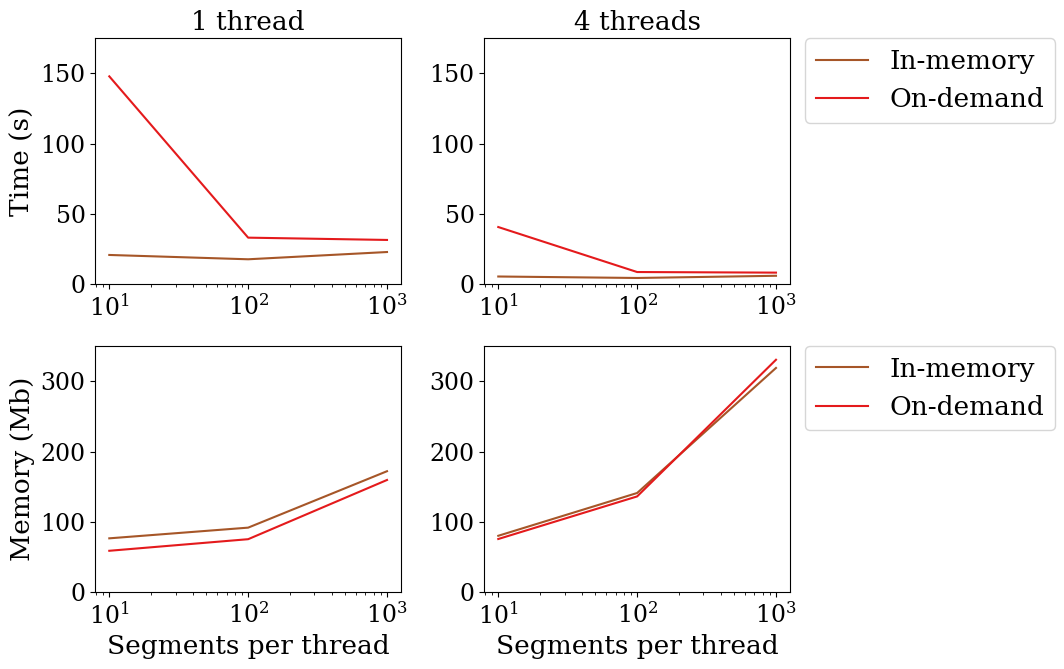

In [160]:
ref_size = "10Mb_equal"
if (ref_size == "10Mb_equal"):
    df = df_cart.copy()
    df = df[df["bins"] == 1024]

df = df[df["seg-count"]==4000]
df = df[df["error-rate"]==0.06]
df = df[df["max-queued-carts"] == 1000]

build = df[df["exec-path"] == "build"].copy()
build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
io = df[df["exec-path"] == "build_io"].copy()
io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

fig, ax = plt.subplots(2, 2)
#fig.set_figheight(8)
fig.set_size_inches(11, 7)

labels = ["In-memory", "On-demand"]

j = 0
for t in [1, 4]:
    i = 0
    for data in [build, io]:
        data = data[data["threads"] == t]
        data = data[data["cart-max-capacity"] > 1]
        data = data[data["max-queued-carts"] == 1000]
        data = data.sort_values('cart-max-capacity', ascending=True)
        data = data.groupby('cart-max-capacity').agg('mean')
        ax[0][j].semilogx(data.index.values, data["Time (s)"], color = colors[i], label = labels[i])
        i += 1
        
    i = 0
    for data in [build, io]:
        data = data[data["threads"] == t]
        data = data[data["cart-max-capacity"] > 1]
        data = data[data["max-queued-carts"] == 1000]
        data = data.sort_values('cart-max-capacity', ascending=True)
        data = data.groupby('cart-max-capacity').agg('mean')
        ax[1][j].set_ylim(0, 350)
        ax[0][j].set_ylim(0, 175)
        ax[1][j].semilogx(data.index.values, data["Memory (kb)"] / 1000, label = labels[i], color = colors[i])
        #ax[1][j].set_xlabel("Cart capacity")
        ax[1][j].set_xlabel("Segments per thread")
        i+=1
    j += 1

ax[0][0].set_title("1 thread")
ax[0][1].set_title("4 threads")

ax[0][0].set_ylabel("Time (s)")
ax[1][0].set_ylabel("Memory (Mb)")

ax[0][1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax[1][1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
#fig.suptitle(r"Searching 10k $\epsilon$(50, 3)-matches between 100Mb reference and 1Mb query")
fig.tight_layout()  # otherwise the right y-label is slightly clipped
fig.savefig(ref_size + "_cart_max_capacity_t.png", dpi=400, bbox_inches='tight')
plt.show()

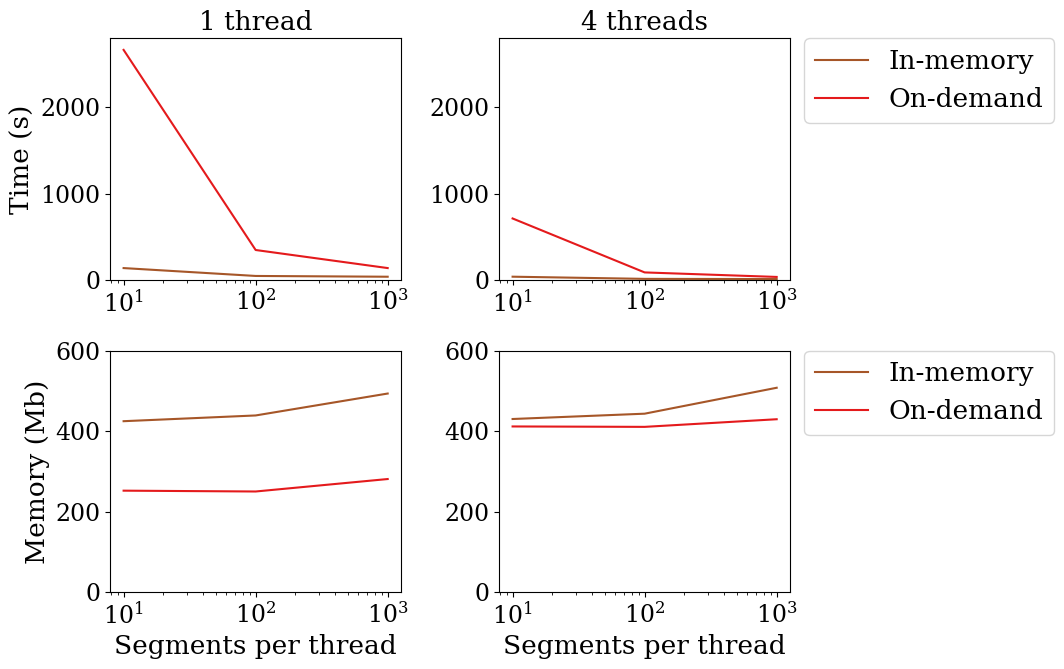

In [161]:
ref_size = "100Mb"
df = get_df(ref_size + "/cart_params_test/full.log")
df = df[df["seg-count"]>3400]
df = df[df["error-rate"]==0.06]
df = df[df["max-queued-carts"] == 1000]
#df["cart-max-capacity"] = df["cart-max-capacity"] * 300 
df.drop(["rep"], inplace = True, axis = 1)

build = df[df["exec-path"] == "build"].copy()
build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
io = df[df["exec-path"] == "build_io"].copy()
io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

fig, ax = plt.subplots(2, 2)
#fig.set_figheight(8)
fig.set_size_inches(11, 7)

labels = ["In-memory", "On-demand"]

j = 0
for t in [1, 4]:
    i = 0
    for data in [build, io]:
        data = data[data["threads"] == t]
        data = data[data["cart-max-capacity"] > 1]
        data = data[data["max-queued-carts"] == 1000]
        data = data.sort_values('cart-max-capacity', ascending=True)
        data = data.groupby('cart-max-capacity').agg('mean')
        ax[0][j].semilogx(data.index.values, data["Time (s)"], color = colors[i], label = labels[i])
        i += 1
        
    i = 0
    for data in [build, io]:
        data = data[data["threads"] == t]
        data = data[data["cart-max-capacity"] > 1]
        data = data[data["max-queued-carts"] == 1000]
        data = data.sort_values('cart-max-capacity', ascending=True)
        data = data.groupby('cart-max-capacity').agg('mean')
        ax[0][j].set_ylim(0, 2800)
        ax[1][j].set_ylim(0, 600)
        ax[1][j].semilogx(data.index.values, data["Memory (kb)"] / 1000, label = labels[i], color = colors[i])
        #ax[1][j].set_xlabel("Cart capacity")
        ax[1][j].set_xlabel("Segments per thread")
        i+=1
    j += 1

ax[0][0].set_title("1 thread")
ax[0][1].set_title("4 threads")

ax[0][0].set_ylabel("Time (s)")
ax[1][0].set_ylabel("Memory (Mb)")

ax[0][1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax[1][1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
#fig.suptitle(r"Searching 10k $\epsilon$(50, 3)-matches between 100Mb reference and 1Mb query")
fig.tight_layout()  # otherwise the right y-label is slightly clipped
fig.savefig(ref_size + "_cart_max_capacity_t.png", dpi=400, bbox_inches='tight')
plt.show()

In [162]:
ref_size = "10Mb_equal"
df = get_no_time_df(ref_size + "/full.log")
np.unique(df["max-queued-carts"])

array([  10,  100, 1000], dtype=int32)

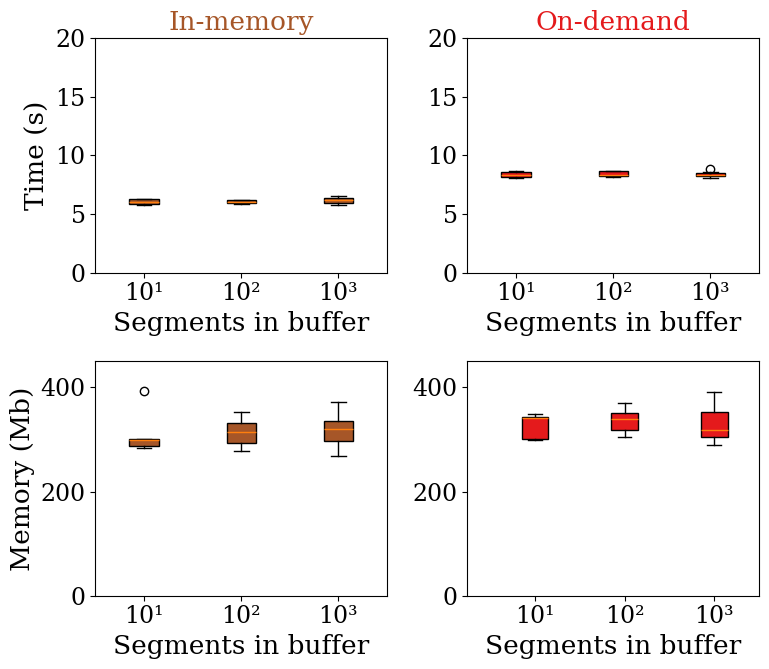

In [163]:
fig, ax = plt.subplots(2, 2, sharey = False)
fig.set_size_inches(8, 7)

#i = 0
data = df_cart.copy()

i = 1

if (i==1):
    df = df[df["seg-count"]==4000]
    df = df[df["error-rate"]==0.06]
    df = df[df["cart-max-capacity"] == 1000]
    #df = df[df["cart-max-capacity"] > 1]
    df = df[df["bins"] == 1024]
    data = df

df_copy = data.copy()

x_cols = ["cart-max-capacity", "max-queued-carts"]
x_col = x_cols[i]

#TODO: how many Mb per 10¹?
colnames = ["Segments per thread", "Segments in buffer"]
colname = colnames[i]

def plot_cols(data, ax, column, color, label):
    
    labels = [r"10¹", r"10²", r"10³"]
    capacities = [10, 100, 1000]
    
    data_list = []
    for c in capacities:
        data_list.append(data[data[x_col]==c][column])
    bplot = ax.boxplot(data_list,
                       patch_artist=True,  # fill with color
                       tick_labels=labels)  # will be used to label x-ticks

    # fill with colors
    local_colors = [color] * len(capacities)
    for patch, color in zip(bplot['boxes'], local_colors):
        patch.set_facecolor(color)

    legend_square = mpatches.Patch(color=color, label=label)
    #ax.legend(handles=[legend_square])

for t in [4]:
    data = data[data["threads"] == t]
    data = data[data[x_cols[not(i)]] == 1000]
    col = x_cols[i]
    data = data.sort_values(col, ascending=True)

    build = data[data["exec-path"] == "build"].copy()
    build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
    io = data[data["exec-path"] == "build_io"].copy()
    io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

    col = "Time (s)"
    plot_cols(io, ax[0][1], col, colors[1], "On-demand")
    plot_cols(build, ax[0][0], col, colors[0], "In-memory")

    ax[0][0].set_title("In-memory", color = colors[0])
    ax[0][1].set_title("On-demand", color = colors[1])
    ax[0][0].set_xlabel(colname)
    ax[0][1].set_xlabel(colname)
    ax[0][0].set_ylabel("Time (s)")
    ax[0][0].set_ylim(0, 50)
    ax[0][1].set_ylim(0, 50)
    if (i==1):
        ax[0][0].set_ylim(0, 20)
        ax[0][1].set_ylim(0, 20)
    
    #ax[0].plot(data[col], data["Time (s)"], linestyle = "dotted", color = colors[i])

    data = df_copy.copy()
    data = data[data["threads"] == t]
    data = data[data[x_cols[not(i)]] == 1000]
    data = data.sort_values(col, ascending=True)

    build = data[data["exec-path"] == "build"].copy()
    build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
    io = data[data["exec-path"] == "build_io"].copy()
    io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

    col = "Memory (kb)"
    io[col] = io[col] / 1000
    build[col] = build[col] / 1000
    plot_cols(io, ax[1][1], col, colors[1], "On-demand")
    plot_cols(build, ax[1][0], col, colors[0], "In-memory")

    ax[1][0].set_ylabel("Memory (Mb)")
    #ax[1][1].set_ylabel("Memory (Mb)")

    ax[1][0].set_xlabel(colname)
    ax[1][1].set_xlabel(colname)
    ax[1][0].set_ylim(0, 450)
    ax[1][1].set_ylim(0, 450)

    ax[1][1].plot(0.4, 0.4, linestyle = "-.", color = colors[0], label = "In-memory")
    ax[1][1].plot(0.4, 400, color = colors[1], label = "On-demand")

    #ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    #fig.suptitle("Searching 10k matches between \n100Mb reference and 1Mb query\n using " + str(t) + " threads")
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    fig.savefig(ref_size + "_" + x_col + "_t" + str(t) + ".png", dpi=400, bbox_inches='tight')
    plt.show()

#### Segment length

In [164]:
def get_df(filename):
    df = pd.read_csv(filename, sep = "\t", header = None)
    df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "adapt_cutoff", "errors", "more"]
    more = df['more'].str.split('--',expand=True)
    df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)

    more.drop([1, 2, 6, 7, 9, 12, 13, 14], axis = 1, inplace = True)
    more[0] = more[0].astype(str)
    more.columns = ["exec-path", "seg-count", "cart-max-capacity", "max-queued-carts", "index", "error-rate", "threads"]
    more["exec-path"] = more["exec-path"].str.removeprefix("/group/ag_abi/evelina/valik/")
    more["exec-path"] = more["exec-path"].str.removesuffix("/bin/dream-stellar search ")

    for col in ["seg-count", "cart-max-capacity", "max-queued-carts", "threads", "error-rate"]:
        more[col] = more[col].str.removeprefix(col)

    col = "index"
    more[col] = more[col].str.removeprefix("index /dev/shm/markov/" + ref_size + "/")
    more[col] = more[col].str.removesuffix(".index ")

    more[["rep", "e", "bins", "end"]] = more[col].str.split('_',expand=True)
    more.drop(["e", "end", "index"], axis = 1, inplace = True)
    
    col = "rep"
    more[col] = more[col].str.removeprefix(col)
    col = "bins"
    more[col] = more[col].str.removeprefix("b")
    
    col = "output-path"
    if col in more.columns:
        more[col] = more[col].str.removeprefix("output /buffer/ag_abi/evelina/markov/")
        more[["ref-size", "type", "er", "output-type"]] = more[col].str.split('/',expand=True)
        more.drop(["output-type", "type"], axis = 1, inplace = True)

    col = "error-rate"
    more[col] = more[col].str.removeprefix("efficiency_")
    more.drop(["rep", "bins"], axis =1, inplace = True)
    
    df = df.merge(more, how = "outer", left_index = True, right_index = True)
    df = df.astype({'Memory (kb)': 'int64', "seg-count": 'int32', "cart-max-capacity": 'int32', "threads": 'int64', "max-queued-carts" : 'int32', "error-rate" : 'float'})
    return df

ref_size = "10Mb_equal"
bin_cutoff = 0.5
dir_name = "seg_len_test"
query_len = 10 * 1024 * 1024

dataframes = []
for er in [0.06]:
    frames = []
    for rep in range(2, 6, 1):    
        er_str = str(er)
        if (er == 0.1):
            er_str = "0.10"
        df = get_df(ref_size + "/read_all/" + dir_name + "/search_efficiency_rep" + str(rep) + "_e" + er_str + ".log")
        acc = pd.read_csv(ref_size + "/read_all/" + dir_name + "/efficiency_rep" + str(rep) + "_e" + er_str + "/valik.stellar.accuracy", sep = "\t", header = None)
        df["adapt_cutoff"] = df["adapt_cutoff"].astype(float)
        df = df[df["adapt_cutoff"] == bin_cutoff]
        acc.drop([0, 6, 8], inplace = True, axis = 1)
        
        acc.columns = ["test-set-matches", "truth-set-matches", "true-positives", "missed", "adapt_cutoff", "seg-count"]
        acc["seg-count"] = acc["seg-count"].str.split("-", expand = True)[5].astype(int)
        #print(acc)
        
        #acc["seg-count"] = 2 * seg_list
        #print(acc)
        df["seg-len"] = (query_len / df["seg-count"]).astype(int)
        
        df = pd.merge(df, acc, on = ["seg-count", "adapt_cutoff"], how = "inner")
        
        frames.append(df)
    data = pd.concat(frames)
    #print(data)
    dataframes.append(data)

    print("bin-cutoff\terror-rate\tseg-count\tseg-len\tmean time (s)\tmean memory (kb)\tmissed")
    for seg_count in np.unique(data["seg-count"]):
        #print(seg_count)
        print(str(bin_cutoff) + "\t" + str(er) + "\t" + str(seg_count) + "\t" +
            str(data[data["seg-count"]==seg_count].iloc[0]["seg-len"]) + "\t" + 
                str(np.round(np.mean(data[data["seg-count"]==seg_count]["Time (s)"]), 2)) + "\t" +  
                    str(int(np.round(np.mean(data[data["seg-count"]==seg_count]["Memory (kb)"]), 2))) + "\t" +
                            str(np.round(np.mean(data[data["seg-count"]==seg_count]["missed"]), 3)))

bin-cutoff	error-rate	seg-count	seg-len	mean time (s)	mean memory (kb)	missed
0.5	0.06	10	1048576	71.58	1389984	0.137
0.5	0.06	20	524288	59.95	1426849	0.055
0.5	0.06	50	209715	51.66	1406708	0.099
0.5	0.06	250	41943	47.89	1359546	0.008
0.5	0.06	500	20971	35.3	1210338	0.007
0.5	0.06	1000	10485	19.7	892896	0.007
0.5	0.06	2000	5242	10.45	533102	0.008
0.5	0.06	4000	2621	6.19	320577	0.008
0.5	0.06	8000	1310	4.46	192662	0.008
0.5	0.06	16000	655	3.57	147300	0.007
0.5	0.06	32000	327	3.24	124558	0.008
0.5	0.06	64000	163	3.19	114805	0.008
0.5	0.06	128000	81	3.51	118274	0.008


In [165]:
d = dataframes[0][["seg-count", "seg-len", "Time (s)", "Memory (kb)", "missed"]]
d = d.groupby('seg-count').agg('mean')
d["seg-len"] = d["seg-len"].astype(int)
d["Memory (Mb)"] = (d["Memory (kb)"] / 1000).astype(int)
d = d.round({"Time (s)" : 1, "missed" : 4})
d.drop(["Memory (kb)"], axis = 1, inplace = True)
d

,seg-len,Time (s),missed,Memory (Mb)
seg-count,,,,
10,1048576,71.6,0.1368,1389
20,524288,60.0,0.0550,1426
50,209715,51.7,0.0989,1406
250,41943,47.9,0.0081,1359
500,20971,35.3,0.0065,1210
1000,10485,19.7,0.0070,892
2000,5242,10.4,0.0075,533
4000,2621,6.2,0.0076,320
8000,1310,4.5,0.0078,192


#### Bin count

In [166]:
def get_df(filename):
    df = pd.read_csv(filename, sep = "\t", header = None)
    df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "adapt_cutoff", "errors", "more"]
    more = df['more'].str.split('--',expand=True)
    df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)

    more.drop([1, 2, 6, 7, 9, 12, 13, 14], axis = 1, inplace = True)
    more[0] = more[0].astype(str)
    more.columns = ["exec-path", "seg-count", "cart-max-capacity", "max-queued-carts", "index", "error-rate", "threads"]
    more["exec-path"] = more["exec-path"].str.removeprefix("/group/ag_abi/evelina/valik/")
    more["exec-path"] = more["exec-path"].str.removesuffix("/bin/dream-stellar search ")

    for col in ["seg-count", "cart-max-capacity", "max-queued-carts", "threads", "error-rate"]:
        more[col] = more[col].str.removeprefix(col)

    col = "index"
    more[col] = more[col].str.removeprefix("index /dev/shm/markov/" + ref_size + "/")
    more[col] = more[col].str.removesuffix(".index ")

    more[["rep", "e", "bins"]] = more[col].str.split('_',expand=True)
    more.drop(["e", "index"], axis = 1, inplace = True)
    
    col = "rep"
    more[col] = more[col].str.removeprefix(col)
    col = "bins"
    more[col] = more[col].str.removeprefix("b")
    
    col = "output-path"
    if col in more.columns:
        more[col] = more[col].str.removeprefix("output /buffer/ag_abi/evelina/markov/")
        more[["ref-size", "type", "er", "output-type"]] = more[col].str.split('/',expand=True)
        more.drop(["output-type", "type"], axis = 1, inplace = True)

    col = "error-rate"
    more[col] = more[col].str.removeprefix("efficiency_")
    df = df.merge(more, how = "outer", left_index = True, right_index = True)
    df = df.dropna()
    df = df[df["rep"] != "seg"]
    df = df.astype({'Memory (kb)': 'int64', "seg-count": 'int32', "cart-max-capacity": 'int32', "threads": 'int64', "max-queued-carts" : 'int32', "error-rate" : 'float', "bins" : 'int32'})
    return df

# bash remove_dist_stellar.sh
ref_size = "10Mb_equal"
bin_cutoff = 0.5
dir_name = "bin_count_test"
bins = [8192, 4096, 2048, 1024, 512, 256, 128, 64]
ref_len = 10 * 1024 * 1024

for er in [0.06]:
    frames = []
    for rep in range(1, 6, 1):
        er_str = str(er)
        if (er == 0.1):
            er_str = "0.10"
        df = get_df(ref_size + "/read_all/" + dir_name + "/search_efficiency_rep" + str(rep) + "_e" + er_str + ".log")
        acc = pd.read_csv(ref_size + "/read_all/" + dir_name + "/efficiency_rep" + str(rep) + "_e" + er_str + "/valik.stellar.accuracy", sep = "\t", header = None)
        
        acc.drop([0, 6, 7, 8], inplace = True, axis = 1)
        acc.columns = ["test-set-matches", "truth-set-matches", "true-positives", "missed", "adapt_cutoff"]
        acc["bins"] = bins
        df = pd.merge(df, acc, on = ["bins", "adapt_cutoff"], how = "inner")
        df["seg-len"] = (ref_len / df["bins"]).astype(int)
        frames.append(df)
    data = pd.concat(frames)
        
    print("bin-cutoff\terror-rate\tbins\tseg-len\tmean time (s)\tmean memory (kb)\tmissed")
    for b in bins[1:]:
        print(str(bin_cutoff) + "\t" + str(er) + "\t" + str(b) + "\t" +
            str(data[data["bins"]==b].iloc[0]["seg-len"]) + "\t" + 
                str(np.round(np.mean(data[data["bins"]==b]["Time (s)"]), 2)) + "\t" +  
                    str(int(np.round(np.mean(data[data["bins"]==b]["Memory (kb)"]), 2))) + "\t" +
                            str(np.round(np.mean(data[data["bins"]==b]["missed"]), 2)))

bin-cutoff	error-rate	bins	seg-len	mean time (s)	mean memory (kb)	missed
0.5	0.06	4096	2560	7.88	244252	0.01
0.5	0.06	2048	5120	6.19	242332	0.01
0.5	0.06	1024	10240	6.12	323242	0.01
0.5	0.06	512	20480	7.61	447841	0.01
0.5	0.06	256	40960	9.62	604384	0.01
0.5	0.06	128	81920	11.21	860035	0.02
0.5	0.06	64	163840	11.17	855464	0.04


In [167]:
d = data[["bins", "seg-len", "Time (s)", "Memory (kb)", "missed"]]
d = d.groupby('bins').agg('mean')
d["seg-len"] = d["seg-len"].astype(int)
d["Memory (Mb)"] = (d["Memory (kb)"] / 1024).astype(int)
#make_timedelta(d, "Time (s)")
d = d.round({"Time (s)" : 1, "missed" : 4})
d.drop(["Memory (kb)"], axis = 1, inplace = True)
d["seg-len"]

bins
64      163840
128      81920
256      40960
512      20480
1024     10240
2048      5120
4096      2560
8192      1280
Name: seg-len, dtype: int64